In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import fsps
from jax import jit
from tqdm import tqdm
from astropy import constants as const
tiny_number = 1e-70

from ceridwen.ssps.ssp_data import SSPData
from ceridwen.csp.csp import CSPBasis, fnu2flam

T_UNIV = 13.8  # Gyr, age of the universe
N_T = 5     # number of time steps for SFH

def gaussian_burst(tau, center_tau, width_tau, amp=1.0):
    """Gaussian in lookback time, evaluated on tau grid (Gyr)."""
    return amp * jnp.exp(-0.5 * ((tau - center_tau) / width_tau)**2)

t = jnp.linspace(1e-2, T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

sfr_bimodal = (gaussian_burst(tau, 0.05, 0.03, 1.0) +
               gaussian_burst(tau, 11.0, 0.8, 0.7))
zh = jnp.full_like(t, 10**-4.3477116)  # constant metallicity (Z=0.02)

ssp_data = SSPData.load('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')

ssp_data.ssp_flux.shape

(12, 108, 5994)

In [2]:
sp = fsps.StellarPopulation(zcontinuous=3, sfh=3, add_neb_emission=False, add_neb_continuum=False)
sp.set_tabular_sfh(age = np.asarray(t), sfr = np.asarray(sfr_bimodal), Z=zh)

In [12]:
diffdust = 2.0
diffdust_index = -0.7
young_dust = 2
young_dust_index = -1


#----------------------------
# FSPS no dust
#----------------------------

sp.params['dust1'] = 0
sp.params['dust2'] = 0
sp.params['dust1_index'] = young_dust_index
sp.params['dust_index'] = diffdust_index

sp.params['add_dust_emission'] = False
sp.params['dust_type'] = 4

wave, spec_fsps_nodust = sp.get_spectrum(tage=13.8) 


#----------------------------
# FSPS diffuse dust
#----------------------------

sp.params['dust1'] = 0
sp.params['dust2'] = diffdust
sp.params['dust1_index'] = young_dust_index
sp.params['dust_index'] = diffdust_index


wave, spec_fsps_diff_dust = sp.get_spectrum(tage=13.8) 


#----------------------------
# FSPS diffuse and young dust
#----------------------------

sp.params['dust1'] = young_dust
sp.params['dust2'] = diffdust
sp.params['dust1_index'] = young_dust_index
sp.params['dust_index'] = diffdust_index


wave, spec_fsps_dusty = sp.get_spectrum(tage=13.8) 

#----------------------------
# FSPS only young dust
#----------------------------

sp.params['dust1'] = young_dust
sp.params['dust2'] = 0
sp.params['dust1_index'] = young_dust_index
sp.params['dust_index'] = diffdust_index


wave, spec_fsps_young_dust = sp.get_spectrum(tage=13.8) 

In [4]:
csp = CSPBasis(ssp_data, theta_dict = {'lookback_time': tau, 'sfh': sfr_bimodal, 'zh': zh}, tuniv = 13.8, tiny_logt = -70, zh_const = False,
                 add_neb = False, init_neb_params = {"isoc_type": "mist", "cloudy_dust": True}, 
                 add_dust = True, add_diffuse_dust = True, add_dust_emission = False, sps_home = '/Users/amanda/Prospector/fsps',
                 init_dust_params = {'bin_edges': [(-jnp.inf, -1.97)], 
                                'laws': ['powerlaw']}, verbose = True)

<class 'ceridwen.csp.csp.DustParams'>
Get spectrum with dust attenuation, but no dust emission or nebular emission
dict_keys(['sfh_times', 'sfh', 'theta_init', 'alpha_idx', 'diffuse_dust_index_idx', 'diffuse_tau_kc_idx', 'sfh_idx', 'tau_pow_idx', 'zh_idx'])


In [5]:
jnp.log10(10000000/1000000000)

Array(-1.9999999, dtype=float32)

# Show that it works with JIT

In [6]:
def run_spectrum(csp, theta):
    return csp.get_spectrum(theta)

# --- Compile the function, marking `csp` as static
run_spectrum_jit = jit(run_spectrum, static_argnums=0)

In [7]:
#----------------------------
# CSP no dust
#----------------------------

theta = jnp.array(csp.theta_init.at[csp.tau_pow_idx].set(0))
theta = jnp.array(theta.at[csp.alpha_idx].set(young_dust_index))
theta = jnp.array(theta.at[csp.diffuse_dust_index_idx].set(diffdust_index))
theta = jnp.array(theta.at[csp.diffuse_tau_kc_idx].set(0))

spectrum_dustfree = run_spectrum_jit(csp, theta)


#----------------------------
# CSP diffuse dust
#----------------------------


theta = jnp.array(csp.theta_init.at[csp.tau_pow_idx].set(0))
theta = jnp.array(theta.at[csp.alpha_idx].set(young_dust_index))
theta = jnp.array(theta.at[csp.diffuse_dust_index_idx].set(diffdust_index))
theta = jnp.array(theta.at[csp.diffuse_tau_kc_idx].set(diffdust))

spectrum_diff_dust = run_spectrum_jit(csp, theta)


#----------------------------
# CSP only young dust
#----------------------------

theta = jnp.array(csp.theta_init.at[csp.tau_pow_idx].set(young_dust))
theta = jnp.array(theta.at[csp.alpha_idx].set(young_dust_index))
theta = jnp.array(theta.at[csp.diffuse_dust_index_idx].set(diffdust_index))
theta = jnp.array(theta.at[csp.diffuse_tau_kc_idx].set(0))

spectrum_young_dust = run_spectrum_jit(csp, theta)



#----------------------------
# CSP diffuse and young dust
#----------------------------

theta = jnp.array(csp.theta_init.at[csp.tau_pow_idx].set(young_dust))
theta = jnp.array(theta.at[csp.alpha_idx].set(young_dust_index))
theta = jnp.array(theta.at[csp.diffuse_dust_index_idx].set(diffdust_index))
theta = jnp.array(theta.at[csp.diffuse_tau_kc_idx].set(diffdust))

spectrum_dusty = run_spectrum_jit(csp, theta)

print(len(theta))


14


In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_sed_comparison_grid(
    wave,
    csp_wave,
    spec_fsps_nodust,
    spectrum_dustfree,
    spec_fsps_diff_dust,
    spectrum_diff_dust,
    spec_fsps_dusty,
    spectrum_dusty,
    spec_fsps_young_dust,
    spectrum_young_dust
):
    fig, axes = plt.subplots(4, 2, figsize=(12, 14), gridspec_kw={"height_ratios": [3, 1] * 2})

    comparisons = [
        ("No Dust", spec_fsps_nodust, spectrum_dustfree),
        ("Diffuse Dust", spec_fsps_diff_dust, spectrum_diff_dust),
        ("All Dust", spec_fsps_dusty, spectrum_dusty),
        ("Young Dust", spec_fsps_young_dust, spectrum_young_dust),
    ]

    for i, (label, fsps_spec, model_spec) in enumerate(comparisons):
        ax_main = axes[i][0]
        ax_resid = axes[i][1]

        # Plot spectra
        ax_main.loglog(wave, fsps_spec, ls = 'dashed', color = 'crimson', label="FSPS", zorder = 200)
        ax_main.loglog(csp_wave, model_spec, label="Model", color = 'dodgerblue')
        ax_main.set_ylabel("Flux")
        if i == 0:
            ax_main.legend()
        ax_main.set_title(label)

        # Interpolate model spec to fsps wavelength for residuals
        interp_model = np.interp(wave, csp_wave, model_spec)
        residuals = (fsps_spec - interp_model) / fsps_spec

        # Plot residuals
        ax_resid.plot(wave, residuals, color="black", lw=0.8)
        ax_resid.axhline(0, color="gray", lw=0.5, linestyle="--")
        ax_resid.set_ylabel("Residual")
        ax_resid.set_xlabel("Wavelength (Å)")
        ax_resid.set_xscale("log")
        ax_resid.set_yscale("symlog")
        ax_resid.set_ylim(-2*1e-3, 2*1e-3)

    plt.tight_layout()
    return fig, axes

In [9]:
sp.params['dust_tesc']

7.0

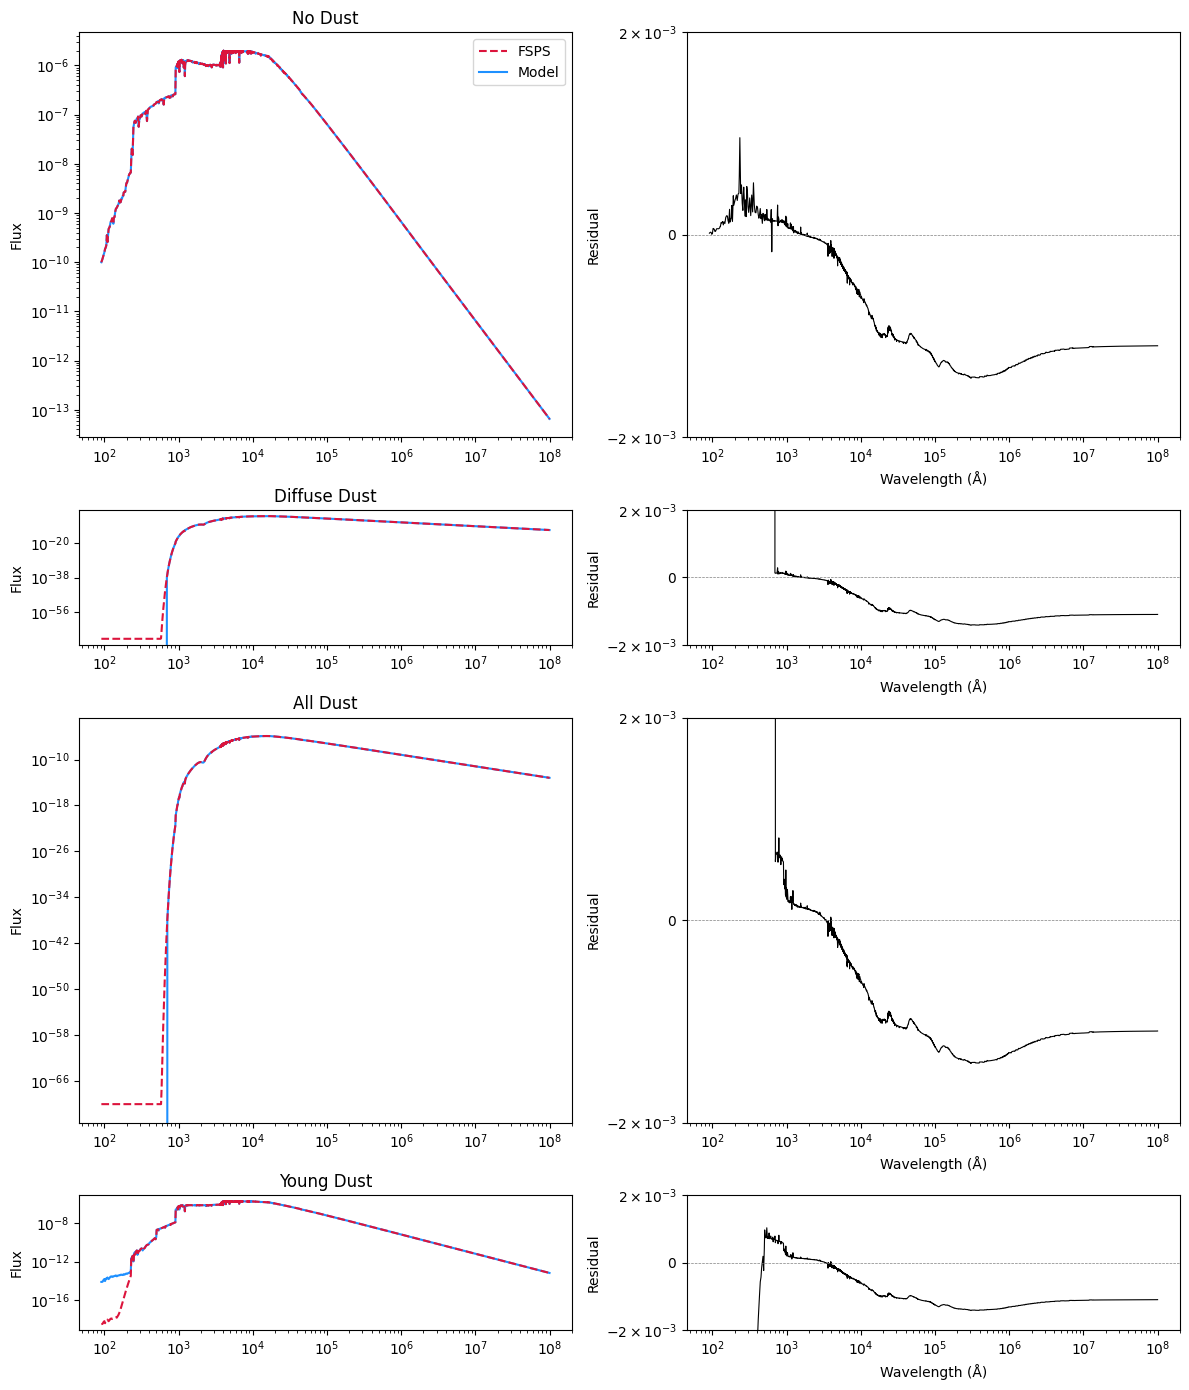

In [10]:
fig, axes = plot_sed_comparison_grid(
    wave,
    csp.wave,
    spec_fsps_nodust,
    spectrum_dustfree,
    spec_fsps_diff_dust,
    spectrum_diff_dust,
    spec_fsps_dusty,
    spectrum_dusty,
    spec_fsps_young_dust,
    spectrum_young_dust
)

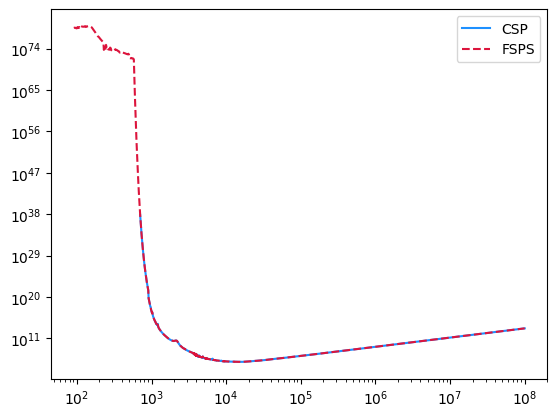

In [11]:


plt.loglog(csp.wave, spectrum_dustfree/spectrum_young_dust/spectrum_diff_dust, color = 'dodgerblue', label = 'CSP')

plt.loglog(wave, spec_fsps_nodust/spec_fsps_young_dust/spec_fsps_diff_dust,ls = 'dashed', color = 'crimson', label = 'FSPS')

plt.legend()

# Try different CSP settings

In [151]:
csp_diff = CSPBasis(ssp_data, theta_dict = {'lookback_time': tau, 'sfh': sfr_bimodal, 'zh': zh}, tuniv = 13.8, tiny_logt = -70, zh_const = False,
                 add_neb = False, init_neb_params = {"isoc_type": "mist", "cloudy_dust": True}, 
                 add_dust = False, add_diffuse_dust = True, add_dust_emission = False, sps_home = '/Users/amanda/Prospector/fsps',
                 init_dust_params = {'bin_edges': [(-jnp.inf, -1.97)], 
                                'laws': ['powerlaw']}, verbose = True)

Get spectrum with no dust attenuation, dust emission, or nebular emission
dict_keys(['sfh_times', 'sfh', 'theta_init', 'diffuse_dust_index_idx', 'diffuse_tau_kc_idx', 'sfh_idx', 'zh_idx'])


In [152]:
#----------------------------
# CSP diffuse dust
#----------------------------

theta_diff = csp_diff.theta_init
theta_diff = jnp.array(theta_diff.at[csp_diff.diffuse_dust_index_idx].set(diffdust))
theta_diff = jnp.array(theta_diff.at[csp_diff.diffuse_tau_kc_idx].set(diffdust_index))

csp_diff_dust = run_spectrum_jit(csp_diff, theta_diff)

In [153]:
len(csp_diff.theta_init)

12

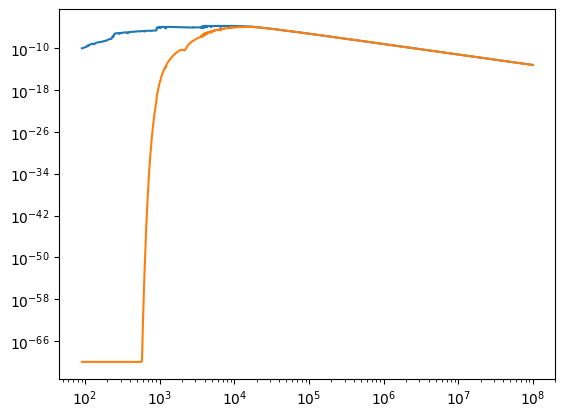

In [154]:
plt.loglog(csp.wave, csp_diff_dust)
plt.loglog(wave, spec_fsps_diff_dust)


In [155]:
csp_young = CSPBasis(ssp_data, theta_dict = {'lookback_time': tau, 'sfh': sfr_bimodal, 'zh': zh}, tuniv = 13.8, tiny_logt = -70, zh_const = False,
                 add_neb = False, init_neb_params = {"isoc_type": "mist", "cloudy_dust": True}, 
                 add_dust = True, add_diffuse_dust = False, add_dust_emission = False, sps_home = '/Users/amanda/Prospector/fsps',
                 init_dust_params = {'bin_edges': [(-jnp.inf, -1.97)], 
                                'laws': ['powerlaw']}, verbose = True)

<class 'ceridwen.csp.csp.DustParams'>
Get spectrum with dust attenuation, but no dust emission or nebular emission
dict_keys(['sfh_times', 'sfh', 'theta_init', 'alpha_idx', 'sfh_idx', 'tau_pow_idx', 'zh_idx'])


In [156]:
#----------------------------
# CSP young dust
#----------------------------

theta_young = csp_young.theta_init
theta_young = jnp.array(theta_young.at[csp_young.alpha_idx].set(young_dust_index))
theta_young = jnp.array(theta_young.at[csp_young.tau_pow_idx].set(young_dust))

csp_young_dust = run_spectrum_jit(csp_young, theta_diff)
print(theta_young)

[ 1.5995981e-03  4.9936724e-01  1.3417476e-06  3.1028850e-20
  2.4935216e-01  4.4904347e-05  4.4904347e-05  4.4904347e-05
  4.4904347e-05  4.4904347e-05  5.0000000e+00 -1.0000000e+00]


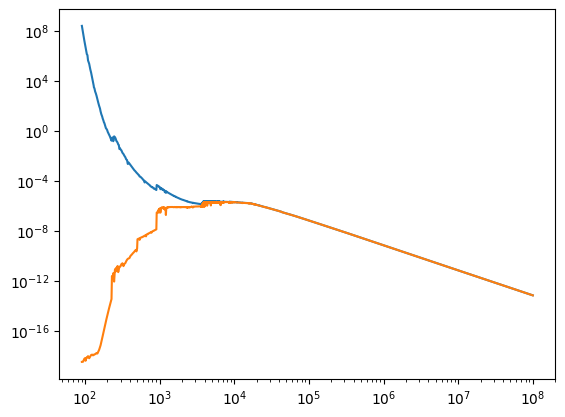

In [157]:
plt.loglog(csp.wave, csp_young_dust)
plt.loglog(wave, spec_fsps_young_dust)